In [1]:
from pathlib import Path
import contextlib
import importlib.util
import io
import sys

import matplotlib.pyplot as plt
import numpy as np
from scipy.io import loadmat
from scipy.ndimage import median_filter
from scipy.signal import medfilt
from scipy.stats import ttest_ind

for candidate in [
    Path.cwd(),
    Path.cwd().parent,
    Path.cwd() / 'miniVI_PlaceCell_analysis_V4',
    Path.cwd().parent / 'miniVI_PlaceCell_analysis_V4',
]:
    spike_detection_path = candidate / 'utils' / 'spike_detection.py'
    if spike_detection_path.exists():
        break
else:
    raise FileNotFoundError('Could not locate miniVI_PlaceCell_analysis_V4/utils/spike_detection.py')

spike_detection_spec = importlib.util.spec_from_file_location('slm_spike_detection_utils', spike_detection_path)
spike_detection_module = importlib.util.module_from_spec(spike_detection_spec)
spike_detection_spec.loader.exec_module(spike_detection_module)

complex_bursts_detection = spike_detection_module.complex_bursts_detection
detect_bursts_from_vm = spike_detection_module.detect_bursts_from_vm
detect_complex_spikes = spike_detection_module.detect_complex_spikes
interpolate_nan_segment = spike_detection_module.interpolate_nan_segment
refine_all_spikes = spike_detection_module.refine_all_spikes
refine_single_spikes = spike_detection_module.refine_single_spikes
spike_height_calculation2 = spike_detection_module.spike_height_calculation2

preprocess_neural_path = candidate / 'utils' / 'preprocess_neural.py'
if not preprocess_neural_path.exists():
    raise FileNotFoundError('Could not locate miniVI_PlaceCell_analysis_V4/utils/preprocess_neural.py')

preprocess_neural_spec = importlib.util.spec_from_file_location('slm_preprocess_neural_utils', preprocess_neural_path)
preprocess_neural_module = importlib.util.module_from_spec(preprocess_neural_spec)
preprocess_neural_spec.loader.exec_module(preprocess_neural_module)

compute_time_varying_snr_from_trace = preprocess_neural_module.compute_time_varying_snr_from_trace

%load_ext autoreload
%autoreload 2

%matplotlib widget

plt.rcParams["svg.fonttype"] = "none"
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 6,
    "axes.labelsize": 6,
    "axes.titlesize": 6,
    "xtick.labelsize": 5,
    "ytick.labelsize": 5,
    "xtick.major.size": 1.75,
    "ytick.major.size": 1.75,
    "xtick.minor.size": 1.0,
    "ytick.minor.size": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "legend.fontsize": 5,
    "axes.linewidth": 0.5,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

sampling_rate_hz = 500
initial_bad_frames = 50
median_filter_window_ms = 101
baseline_window_ms = 100
COLOR_1X = '#009E73'  # Okabe-Ito bluish green: reads as better / healthier
COLOR_20X = '#8C2D04'  # dark reddish brown: reads as worse / stressed, high contrast vs 1x green
median_filter_window_samples = max(1, int(round(median_filter_window_ms * sampling_rate_hz / 1000)))
if median_filter_window_samples % 2 == 0:
    median_filter_window_samples += 1
baseline_window_samples = max(1, int(round(baseline_window_ms * sampling_rate_hz / 1000)))

def interpolate_trace(trace, n_bad_frames=0):
    interpolated = np.asarray(trace, dtype=float).copy()
    interpolated[:n_bad_frames] = np.nan
    nan_mask = np.isnan(interpolated)
    if not nan_mask.any():
        return interpolated
    valid_idx = np.flatnonzero(~nan_mask)
    if valid_idx.size == 0:
        raise ValueError('Trace contains no valid samples after masking bad frames.')
    interpolated[nan_mask] = np.interp(np.flatnonzero(nan_mask), valid_idx, interpolated[valid_idx])
    return interpolated



In [2]:

slm_root = Path('/Volumes/QixinT9/AdamLab/Data/SLM_data')

trace_lists = {'1x': [], '20x': []}
trace_info = {'1x': [], '20x': []}

for folder in sorted(slm_root.iterdir()):
    if not folder.is_dir():
        continue

    folder_name = folder.name
    if folder_name.endswith('_1x'):
        slm_size = '1x'
    elif folder_name.endswith('_20x'):
        slm_size = '20x'
    else:
        continue

    mat_files = sorted(
        path for path in folder.glob('*.mat')
        if not path.name.startswith('._')
    )
    if not mat_files:
        continue

    mat_path = mat_files[0]
    mat_data = loadmat(mat_path)
    if 'intens' not in mat_data:
        raise KeyError(f"'intens' trace not found in {mat_path}")

    trace = np.asarray(mat_data['intens'], dtype=float).squeeze()
    trace = interpolate_trace(trace, n_bad_frames=initial_bad_frames)
    trace_lists[slm_size].append(trace)
    trace_info[slm_size].append(
        {
            'folder': folder_name,
            'mat_file': mat_path.name,
        }
    )

traces_1x = np.stack(trace_lists['1x'])
traces_20x = np.stack(trace_lists['20x'])

print(f"Loaded {traces_1x.shape[0]} traces for 1x: {traces_1x.shape}")
print(f"Loaded {traces_20x.shape[0]} traces for 20x: {traces_20x.shape}")
print(f'Interpolated the first {initial_bad_frames} frames of each trace before analysis.')


Loaded 11 traces for 1x: (11, 300000)
Loaded 6 traces for 20x: (6, 300000)
Interpolated the first 50 frames of each trace before analysis.


Median filter overlay: 101 ms (51 samples at 500 Hz)


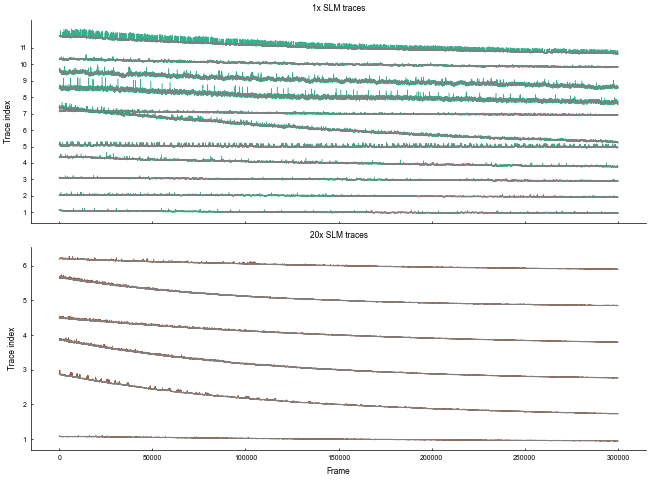

In [3]:
def plot_stacked_traces(ax, traces, title, color):
    filtered_traces = np.vstack([
        medfilt(trace, kernel_size=median_filter_window_samples)
        for trace in traces
    ])
    baseline = np.median(traces, axis=1, keepdims=True)
    centered = traces - baseline
    centered_filtered = filtered_traces - baseline
    amplitudes = np.ptp(centered, axis=1)
    positive_amplitudes = amplitudes[amplitudes > 0]
    spacing = np.median(positive_amplitudes) * 1.2 if positive_amplitudes.size else 1.0

    x = np.arange(traces.shape[1])
    offsets = np.arange(traces.shape[0]) * spacing

    for idx, trace in enumerate(centered):
        ax.plot(x, trace + offsets[idx], color=color, linewidth=0.35, alpha=0.8)
        ax.plot(
            x,
            centered_filtered[idx] + offsets[idx],
            color='0.5',
            linewidth=0.8,
        )

    ax.set_title(title)
    ax.set_ylabel('Trace index')
    ax.set_yticks(offsets)
    ax.set_yticklabels(np.arange(1, traces.shape[0] + 1))
    ax.tick_params(length=1.75, width=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig, axes = plt.subplots(2, 1, figsize=(6.5, 4.8), sharex=True, constrained_layout=True)

plot_stacked_traces(axes[0], traces_1x, '1x SLM traces', COLOR_1X)
plot_stacked_traces(axes[1], traces_20x, '20x SLM traces', COLOR_20X)

axes[1].set_xlabel('Frame')
print(
    f'Median filter overlay: {median_filter_window_ms} ms '
    f'({median_filter_window_samples} samples at {sampling_rate_hz} Hz)'
)
plt.show()


In [4]:
def normalize_traces_to_filtered_baseline(traces):
    filtered_traces = np.vstack([
        medfilt(trace, kernel_size=median_filter_window_samples)
        for trace in traces
    ])
    baselines = filtered_traces[:, :baseline_window_samples].mean(axis=1, keepdims=True)
    if np.any(baselines == 0):
        raise ValueError('A baseline value is zero; cannot normalize traces.')
    normalized_traces = traces / baselines * 100
    normalized_filtered_traces = filtered_traces / baselines * 100
    return filtered_traces, baselines, normalized_traces, normalized_filtered_traces

filtered_traces_1x, baselines_1x, normalized_traces_1x, normalized_filtered_traces_1x = normalize_traces_to_filtered_baseline(traces_1x)
filtered_traces_20x, baselines_20x, normalized_traces_20x, normalized_filtered_traces_20x = normalize_traces_to_filtered_baseline(traces_20x)
time_s = np.arange(traces_1x.shape[1]) / sampling_rate_hz

print(
    f'Normalized to the first {baseline_window_ms} ms '
    f'({baseline_window_samples} samples) of the median-filtered raw trace.'
)
print(
    f'1x baseline range: {baselines_1x.min():.2f} to {baselines_1x.max():.2f}; '
    f'20x baseline range: {baselines_20x.min():.2f} to {baselines_20x.max():.2f}'
)


Normalized to the first 100 ms (50 samples) of the median-filtered raw trace.
1x baseline range: 543.51 to 2548.26; 20x baseline range: 758.31 to 1719.38


Welch t-test on decay: p=0.00443
Saved summary figure to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/Figure1_code/SLM_comparison_summary.svg using trace step 75


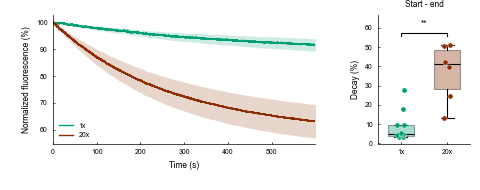

In [5]:
summary_export_max_points = 4000
summary_export_step = max(1, int(np.ceil(time_s.size / summary_export_max_points)))

def plot_mean_sem(ax, traces, label, color, step=1):
    mean_trace = traces.mean(axis=0)
    sem_trace = traces.std(axis=0, ddof=1) / np.sqrt(traces.shape[0])
    plot_time = time_s[::step]
    plot_mean = mean_trace[::step]
    plot_sem = sem_trace[::step]
    ax.plot(plot_time, plot_mean, color=color, linewidth=1.0, label=label)
    ax.fill_between(plot_time, plot_mean - plot_sem, plot_mean + plot_sem, color=color, alpha=0.2, linewidth=0)

def compute_decay(traces):
    start_mean = traces[:, :baseline_window_samples].mean(axis=1)
    end_mean = traces[:, -baseline_window_samples:].mean(axis=1)
    return start_mean - end_mean

def p_to_stars(p_value):
    if p_value < 0.001:
        return '***'
    if p_value < 0.01:
        return '**'
    if p_value < 0.05:
        return '*'
    return ''

decay_1x = compute_decay(normalized_filtered_traces_1x)
decay_20x = compute_decay(normalized_filtered_traces_20x)
decay_ttest = ttest_ind(decay_1x, decay_20x, equal_var=False)
summary_figure_path = Path('/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/Figure1_code/SLM_comparison_summary.svg')

def build_summary_figure(trace_step=1):
    fig, (ax_trace, ax_box) = plt.subplots(
        1,
        2,
        figsize=(4.8, 1.9),
        gridspec_kw={'width_ratios': [3.4, 1.2]},
    )

    plot_mean_sem(ax_trace, normalized_filtered_traces_1x, '1x', COLOR_1X, step=trace_step)
    plot_mean_sem(ax_trace, normalized_filtered_traces_20x, '20x', COLOR_20X, step=trace_step)

    ax_trace.set_xlabel('Time (s)')
    ax_trace.set_ylabel('Normalized fluorescence (%)')
    ax_trace.tick_params(length=1.75, width=0.5)
    ax_trace.spines['top'].set_visible(False)
    ax_trace.spines['right'].set_visible(False)
    ax_trace.legend(frameon=False)
    ax_trace.margins(x=0)

    box = ax_box.boxplot(
        [decay_1x, decay_20x],
        tick_labels=['1x', '20x'],
        widths=0.55,
        patch_artist=True,
        medianprops={'color': 'black', 'linewidth': 0.8},
        boxprops={'linewidth': 0.8},
        whiskerprops={'linewidth': 0.8},
        capprops={'linewidth': 0.8},
        showfliers=False,
    )
    for patch, color in zip(box['boxes'], [COLOR_1X, COLOR_20X]):
        patch.set_facecolor(color)
        patch.set_alpha(0.35)

    rng = np.random.default_rng(0)
    for x_pos, values, color in zip([1, 2], [decay_1x, decay_20x], [COLOR_1X, COLOR_20X]):
        jitter = rng.uniform(-0.08, 0.08, size=values.shape[0])
        ax_box.scatter(
            np.full(values.shape[0], x_pos) + jitter,
            values,
            s=14,
            color=color,
            edgecolors='white',
            linewidths=0.3,
            zorder=3,
        )

    y_min = min(decay_1x.min(), decay_20x.min())
    y_max = max(decay_1x.max(), decay_20x.max())
    y_range = y_max - y_min if y_max > y_min else 1.0
    line_y = y_max + 0.1 * y_range
    text_y = y_max + 0.18 * y_range
    ax_box.plot([1, 1, 2, 2], [line_y, line_y + 0.03 * y_range, line_y + 0.03 * y_range, line_y], color='black', linewidth=0.8)
    ax_box.text(1.5, text_y, p_to_stars(decay_ttest.pvalue), ha='center', va='bottom', fontsize=6)
    ax_box.set_ylim(y_min - 0.08 * y_range, y_max + 0.32 * y_range)

    ax_box.set_ylabel('Decay (%)')
    ax_box.set_title('Start - end')
    ax_box.tick_params(length=1.75, width=0.5)
    ax_box.spines['top'].set_visible(False)
    ax_box.spines['right'].set_visible(False)

    fig.subplots_adjust(left=0.11, right=0.98, bottom=0.24, top=0.92, wspace=0.35)
    return fig

print(f"Welch t-test on decay: p={decay_ttest.pvalue:.3g}")
fig = build_summary_figure(trace_step=1)
export_fig = build_summary_figure(trace_step=summary_export_step)
export_fig.savefig(summary_figure_path, format='svg', bbox_inches='tight')
plt.close(export_fig)
print(f'Saved summary figure to {summary_figure_path} using trace step {summary_export_step}')
plt.show()


1x mapping (bottom = 1, top = 11):
  1: pAce21_PR_cell3_1x | decay=3.23%
  2: pAce21_BR_cell3_1x | decay=3.27%
  3: pAce21_BR_cell2_1x | decay=3.79%
  4: pAce34_BL_cell2_1x | decay=4.23%
  5: pAce21_BR_cell5_1x | decay=4.33%
  6: pAce46_PX_cell2_1x | decay=4.64%
  7: pAce46_PX_cell8_1x | decay=5.55%
  8: pAce46_PX_cell9_1x | decay=9.29%
  9: pAce21_PR_cell2_1x | decay=9.73%
  10: pAce52_PRL_cell3_1x | decay=17.93%
  11: pAce34_BL_cell14_1x | decay=27.61%
20x mapping (bottom = 1, top = 6):
  1: pAce21_BR_cell7_20x | decay=13.11%
  2: pAce52_PRL_cell1_20x | decay=24.34%
  3: pAce34_BL_cell3_20x | decay=39.74%
  4: pAce34_BL_cell8_20x | decay=42.22%
  5: pAce34_BL_cell10_20x | decay=50.72%
  6: pAce24_WR_cell7_20x | decay=51.25%
Saved stacked normalized trace figure to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/Figure1_code/SLM_comparison_normalized_stacked.svg


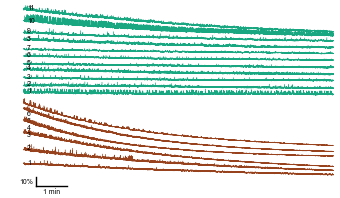

In [6]:
def prepare_sorted_centered_traces(traces, decay_reference_traces, trace_metadata):
    decay = compute_decay(decay_reference_traces)
    sort_idx = np.argsort(decay)
    sorted_traces = traces[sort_idx]
    centered = sorted_traces - np.median(sorted_traces, axis=1, keepdims=True)
    sorted_metadata = [trace_metadata[idx] for idx in sort_idx]
    return centered, decay[sort_idx], sorted_metadata

centered_1x, sorted_decay_1x, sorted_info_1x = prepare_sorted_centered_traces(normalized_traces_1x, normalized_filtered_traces_1x, trace_info['1x'])
centered_20x, sorted_decay_20x, sorted_info_20x = prepare_sorted_centered_traces(normalized_traces_20x, normalized_filtered_traces_20x, trace_info['20x'])

global_max_decay = max(sorted_decay_1x.max(), sorted_decay_20x.max())
shared_half_range = max(5.0, 0.5 * global_max_decay)
shared_ylim = (-shared_half_range, shared_half_range)

def add_scale_bars(ax, y_limits, vertical_bar_height=10.0, horizontal_bar_width_s=60.0):
    x_left = time_s[0] + 0.04 * (time_s[-1] - time_s[0])
    x_right = x_left + horizontal_bar_width_s
    y0 = y_limits[0] + 0.14 * (y_limits[1] - y_limits[0])
    ax.plot([x_left, x_left], [y0, y0 + vertical_bar_height], color='black', linewidth=1.0, clip_on=False)
    ax.text(x_left - time_s[-1] * 0.01, y0 + vertical_bar_height / 2, '10%', ha='right', va='center', fontsize=5)
    ax.plot([x_left, x_right], [y0, y0], color='black', linewidth=1.0, clip_on=False)
    ax.text((x_left + x_right) / 2, y0 - 0.06 * (y_limits[1] - y_limits[0]), '1 min', ha='center', va='top', fontsize=5)

stacked_normalized_figure_path = Path('/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/Figure1_code/SLM_comparison_normalized_stacked.svg')
group_sizes = [centered_1x.shape[0], centered_20x.shape[0]]
inter_group_gap_rows = 5
total_rows = sum(group_sizes) + inter_group_gap_rows * (len(group_sizes) - 1)
fig, axes = plt.subplots(total_rows, 1, figsize=(3.4, total_rows * 0.09), sharex=True, sharey=True)
if total_rows == 1:
    axes = np.array([axes])

for ax in axes.ravel():
    ax.set_visible(False)

condition_specs = [
    (centered_1x, COLOR_1X),
    (centered_20x, COLOR_20X),
]

for condition_label, sorted_info, sorted_decay in [
    ('1x', sorted_info_1x, sorted_decay_1x),
    ('20x', sorted_info_20x, sorted_decay_20x),
]:
    print(f'{condition_label} mapping (bottom = 1, top = {len(sorted_info)}):')
    for rank, (info, decay_value) in enumerate(zip(sorted_info, sorted_decay), start=1):
        print(f"  {rank}: {info['folder']} | decay={decay_value:.2f}%")

row_cursor = 0
for group_idx, (centered_traces, color) in enumerate(condition_specs):
    n_traces = centered_traces.shape[0]
    for rank, trace in enumerate(centered_traces):
        row_idx = row_cursor + (n_traces - 1 - rank)
        ax = axes[row_idx]
        ax.set_visible(True)
        ax.patch.set_alpha(0)
        ax.plot(time_s, trace, color=color, linewidth=0.25, alpha=0.9, clip_on=False)
        ax.set_ylim(shared_ylim)
        ax.margins(x=0, y=0)
        ax.spines['top'].set_visible(False)
        ax.spines['left'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['bottom'].set_visible(False)
        ax.tick_params(axis='y', left=False, labelleft=False)
        ax.tick_params(axis='x', bottom=False, labelbottom=False)
        if group_idx == len(condition_specs) - 1 and rank == 0:
            add_scale_bars(ax, shared_ylim)
        label_x = time_s[0] + 0.01 * (time_s[-1] - time_s[0])
        label_idx = np.searchsorted(time_s, label_x)
        label_window = trace[max(0, label_idx - 5):min(trace.size, label_idx + 6)]
        label_vertical_offset = 1.5
        label_y = np.clip(label_window.mean() + label_vertical_offset, shared_ylim[0] + 1.0, shared_ylim[1] - 1.0)
        ax.text(label_x, label_y, str(rank + 1), ha='left', va='center', fontsize=5)
    row_cursor += n_traces
    if group_idx < len(condition_specs) - 1:
        row_cursor += inter_group_gap_rows

fig.subplots_adjust(left=0.07, right=0.98, bottom=0.03, top=0.99, hspace=-0.84)
fig.savefig(stacked_normalized_figure_path, format='svg', bbox_inches='tight')
print(f'Saved stacked normalized trace figure to {stacked_normalized_figure_path}')
plt.show()


# Spike detection

In [12]:
spike_detection_params = {
    'baseline_window_s': 10,
    'pnorm_CS': 0.5,
    'process_window_CS': 300000,
    'simple_threshold_round1_CB': 50,
    'simple_threshold_round2_CB': 4,
    'pnorm_SS': 0.5,
    'process_window_SS': 300000,
    'simple_threshold_SS': 5.,
    'f_hp': 20,
    'f_hp_CS': 1,
    'SS_height_cap': 0.7,
    'complex_spike_threshold': [0.7, 0.6],
    'highpass': 2,
    'median_window': 11,
    'cb_amp_threshold': 0.4,
    'cb_duration_threshold': 20,
    'plateau_amp_threshold': 0.8,
    'plateau_duration_threshold': 100,
    'plateau_kernel_ms': 100,
    'plateau_score_min_ms': 80,
    'isi_threshold_ms': 20,
}

spike_stack_export_max_points = 6000
spike_stack_export_step = max(1, int(np.ceil(time_s.size / spike_stack_export_max_points)))
spike_stack_figure_path = Path('/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/Figure1_code/SLM_comparison_snr_spike_stacked.svg')

def run_slm_spike_detection(trace):
    trace = np.asarray(trace, dtype=float)
    initial_spikes = np.array([], dtype=np.int64)
    nan_mask = np.isnan(trace)

    baseline_window = max(1, int(round(spike_detection_params['baseline_window_s'] * sampling_rate_hz)))
    if baseline_window % 2 == 0:
        baseline_window += 1
    trace_baseline = median_filter(interpolate_nan_segment(trace.copy()), size=baseline_window)
    trace_baseline_subtracted = trace - trace_baseline
    trace_baseline_subtracted[nan_mask] = np.nan

    with contextlib.redirect_stdout(io.StringIO()):
        complex_bursts_round1, trace_mf_round1, *_ = complex_bursts_detection(
            trace_baseline_subtracted,
            initial_spikes,
            sampling_rate_hz,
            pnorm=spike_detection_params['pnorm_CS'],
            process_window=spike_detection_params['process_window_CS'],
            plotflag=False,
            CB_detection_method='simple',
            simple_threshold=spike_detection_params['simple_threshold_round1_CB'],
            separate_by_sessions=False,
            session_start_frames=None,
            f_hp=spike_detection_params['f_hp_CS'],
        )

        refined_ss_round1, trace_noCS_round1 = refine_single_spikes(
            trace_baseline_subtracted,
            initial_spikes,
            complex_bursts_round1,
            sampling_rate_hz,
            process_window=spike_detection_params['process_window_SS'],
            pnorm=spike_detection_params['pnorm_SS'],
            f_hp=spike_detection_params['f_hp'],
            min_spikes=10,
            plotflag=False,
            separate_by_sessions=False,
            session_start_frames=None,
            SS_detection_method='simple',
            simple_threshold_SS=spike_detection_params['simple_threshold_SS'],
        )

        spike_heights_interpolated, SNR_interpolated = spike_height_calculation2(
            refined_ss_round1,
            trace_baseline_subtracted,
            trace_mf_round1,
            trace_noCS_round1,
            sampling_rate_hz,
            plotflag=False,
            session_start_frames=None,
        )

        with np.errstate(divide='ignore', invalid='ignore'):
            trace_snr_input = trace_baseline_subtracted / spike_heights_interpolated
        trace_snr_input[~np.isfinite(trace_snr_input)] = np.nan

        complex_bursts_round2, *_ = complex_bursts_detection(
            trace_snr_input,
            refined_ss_round1,
            sampling_rate_hz,
            pnorm=spike_detection_params['pnorm_CS'],
            process_window=spike_detection_params['process_window_CS'],
            plotflag=False,
            CB_detection_method='simple',
            simple_threshold=spike_detection_params['simple_threshold_round2_CB'],
            separate_by_sessions=False,
            session_start_frames=[0],
            f_hp=spike_detection_params['f_hp_CS'],
        )

        refined_ss_round2, _ = refine_single_spikes(
            trace_snr_input,
            refined_ss_round1,
            complex_bursts_round2,
            sampling_rate_hz,
            process_window=spike_detection_params['process_window_SS'],
            pnorm=spike_detection_params['pnorm_SS'],
            f_hp=spike_detection_params['f_hp'],
            min_spikes=10,
            plotflag=False,
            separate_by_sessions=False,
            session_start_frames=[0],
            SS_detection_method='simple',
            simple_threshold_SS=spike_detection_params['simple_threshold_SS'],
            SS_height_cap=spike_detection_params['SS_height_cap'],
        )

        CS_spikes = detect_complex_spikes(
            trace_snr_input,
            complex_bursts_round2,
            np.ones_like(trace_snr_input),
            threshold=spike_detection_params['complex_spike_threshold'],
            plotflag=False,
        )

        complex_bursts_round2, refined_ss_round2, all_CS_spikes, all_spikes = refine_all_spikes(
            complex_bursts_round2,
            CS_spikes,
            refined_ss_round2,
        )

        simple_spikes_final, complex_spikes_final, all_spikes_final, trace_SNR_interpolated, Vm, burst_metrics, complex_bursts_dict_vm, plateaus_dict = detect_bursts_from_vm(
            trace_snr_input,
            np.ones_like(trace_snr_input),
            complex_bursts_round2,
            all_spikes,
            sampling_rate_hz,
            highpass=spike_detection_params['highpass'],
            median_window=spike_detection_params['median_window'],
            cb_amp_threshold=spike_detection_params['cb_amp_threshold'],
            cb_duration_threshold=spike_detection_params['cb_duration_threshold'],
            isi_threshold_ms=spike_detection_params['isi_threshold_ms'],
            baseline_subtract=False,
            baseline_window_ms=20,
            baseline_percentile=None,
            merge_SS_ms=None,
            merge_CB_ms=None,
            plateau_amp_threshold=spike_detection_params['plateau_amp_threshold'],
            plateau_duration_threshold=spike_detection_params['plateau_duration_threshold'],
            plateau_kernel_ms=spike_detection_params['plateau_kernel_ms'],
            plateau_score_min_ms=spike_detection_params['plateau_score_min_ms'],
            plotflag=False,
        )

    return {
        'refined_SS_round1': refined_ss_round1,
        'spike_heights_interpolated': spike_heights_interpolated,
        'SNR_interpolated': SNR_interpolated,
        'trace_SNR_interpolated': trace_SNR_interpolated,
        'simple_spikes': simple_spikes_final,
        'complex_spikes': complex_spikes_final,
        'all_spikes': all_spikes_final,
        'Vm': Vm,
        'burst_metrics': burst_metrics,
        'complex_bursts_dict': complex_bursts_dict_vm,
        'plateaus_dict': plateaus_dict,
    }

spike_results = {'1x': [], '20x': []}
for condition_label, traces in [('1x', traces_1x), ('20x', traces_20x)]:
    print(f'Running spike detection for {condition_label}...')
    for cell_idx, trace in enumerate(traces, start=1):
        print(f'  {condition_label} cell {cell_idx}/{traces.shape[0]}')
        spike_results[condition_label].append(run_slm_spike_detection(trace))

def sort_spike_results(condition_label, decay_reference_traces):
    decay = compute_decay(decay_reference_traces)
    sort_idx = np.argsort(decay)
    sorted_results = [spike_results[condition_label][idx] for idx in sort_idx]
    sorted_info = [trace_info[condition_label][idx] for idx in sort_idx]
    sorted_decay = decay[sort_idx]
    return sorted_results, sorted_info, sorted_decay

sorted_spike_results_1x, sorted_spike_info_1x, sorted_spike_decay_1x = sort_spike_results('1x', normalized_filtered_traces_1x)
sorted_spike_results_20x, sorted_spike_info_20x, sorted_spike_decay_20x = sort_spike_results('20x', normalized_filtered_traces_20x)

for condition_label, sorted_info, sorted_decay in [
    ('1x', sorted_spike_info_1x, sorted_spike_decay_1x),
    ('20x', sorted_spike_info_20x, sorted_spike_decay_20x),
]:
    print(f'{condition_label} spike plot mapping (bottom = 1, top = {len(sorted_info)}):')
    for rank, (info, decay_value) in enumerate(zip(sorted_info, sorted_decay), start=1):
        print(f"  {rank}: {info['folder']} | decay={decay_value:.2f}%")

def build_spike_stack_rows():
    rows = []
    for results, color in [
        (sorted_spike_results_1x, COLOR_1X),
        (sorted_spike_results_20x, COLOR_20X),
    ]:
        for rank, result in enumerate(results, start=1):
            trace = np.asarray(result['trace_SNR_interpolated'], dtype=float)
            spikes = np.asarray(result['all_spikes'], dtype=np.int64)
            spikes = spikes[(spikes >= 0) & (spikes < time_s.size)]
            rows.append(
                {
                    'condition': '1x' if color == COLOR_1X else '20x',
                    'label': str(rank),
                    'color': color,
                    'trace': trace,
                    'spikes': spikes,
                }
            )
        if color == COLOR_1X:
            rows.extend([None, None])
    return rows





Running spike detection for 1x...
  1x cell 1/11
  1x cell 2/11
  1x cell 3/11
  1x cell 4/11
  1x cell 5/11
  1x cell 6/11
  1x cell 7/11
  1x cell 8/11
  1x cell 9/11
  1x cell 10/11
  1x cell 11/11
Running spike detection for 20x...
  20x cell 1/6
  20x cell 2/6
  20x cell 3/6
  20x cell 4/6
  20x cell 5/6
  20x cell 6/6
1x spike plot mapping (bottom = 1, top = 11):
  1: pAce21_PR_cell3_1x | decay=3.23%
  2: pAce21_BR_cell3_1x | decay=3.27%
  3: pAce21_BR_cell2_1x | decay=3.79%
  4: pAce34_BL_cell2_1x | decay=4.23%
  5: pAce21_BR_cell5_1x | decay=4.33%
  6: pAce46_PX_cell2_1x | decay=4.64%
  7: pAce46_PX_cell8_1x | decay=5.55%
  8: pAce46_PX_cell9_1x | decay=9.29%
  9: pAce21_PR_cell2_1x | decay=9.73%
  10: pAce52_PRL_cell3_1x | decay=17.93%
  11: pAce34_BL_cell14_1x | decay=27.61%
20x spike plot mapping (bottom = 1, top = 6):
  1: pAce21_BR_cell7_20x | decay=13.11%
  2: pAce52_PRL_cell1_20x | decay=24.34%
  3: pAce34_BL_cell3_20x | decay=39.74%
  4: pAce34_BL_cell8_20x | decay=42.2

Saved SNR spike stack figure to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/Figure1_code/SLM_comparison_snr_spike_stacked.svg using trace step 50


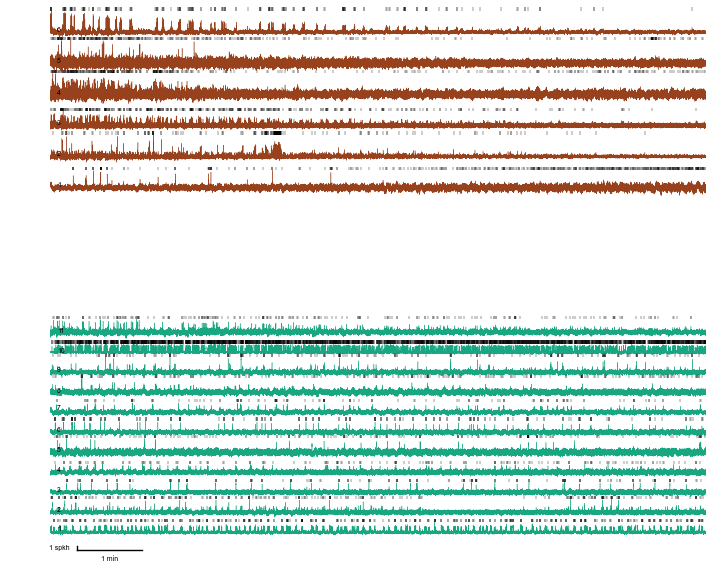

In [13]:
trace_row_offset_1x = 4.5
trace_row_offset_20x = 7.0
spike_stack_rows = build_spike_stack_rows()

finite_trace_values = []
for row in spike_stack_rows:
    if row is None:
        continue
    finite = row['trace'][np.isfinite(row['trace'])]
    if finite.size:
        finite_trace_values.append(finite)

if finite_trace_values:
    finite_trace_values = np.concatenate(finite_trace_values)
    trace_min = float(np.nanmin(finite_trace_values))
    trace_max = float(np.nanmax(finite_trace_values))
else:
    trace_min = 0.0
    trace_max = 1.0

trace_span = max(1.0, trace_max - trace_min)
inter_group_gap_rows = 2
raster_height = max(0.12, 0.1 * trace_span)
raster_gap = max(0.08, 0.06 * trace_span)
raster_base_offset = trace_max + raster_gap


def add_spike_stack_scale_bars(ax, y_base, horizontal_bar_width_s=60.0):
    x_left = time_s[0] + 0.04 * (time_s[-1] - time_s[0])
    x_right = x_left + horizontal_bar_width_s
    ax.plot([x_left, x_left], [y_base, y_base + 1.0], color='black', linewidth=1.0)
    ax.text(x_left - 0.01 * (time_s[-1] - time_s[0]), y_base + 0.5, '1 spkh', ha='right', va='center', fontsize=5)
    ax.plot([x_left, x_right], [y_base, y_base], color='black', linewidth=1.0)
    ax.text((x_left + x_right) / 2, y_base - 0.18 * trace_span, '1 min', ha='center', va='top', fontsize=5)


def build_snr_spike_stack_figure(plot_step=1):
    fig, ax = plt.subplots(figsize=(7.2, 0.3 * len(spike_stack_rows)))

    current_offset = 0.0
    max_trace_top = trace_max
    for row in spike_stack_rows:
        if row is None:
            current_offset += inter_group_gap_rows * max(trace_row_offset_1x, trace_row_offset_20x)
            continue

        trace_row_offset = trace_row_offset_1x if row['condition'] == '1x' else trace_row_offset_20x
        aligned_trace = row['trace'] + current_offset
        ax.plot(time_s[::plot_step], aligned_trace[::plot_step], color=row['color'], linewidth=0.3, alpha=0.9)

        if row['spikes'].size:
            displayed_trace_max = np.nanmax(aligned_trace)
            if not np.isfinite(displayed_trace_max):
                displayed_trace_max = current_offset + trace_max
            raster_y0 = displayed_trace_max
            raster_y1 = raster_y0 + raster_height
            ax.vlines(time_s[row['spikes']], raster_y0, raster_y1, color='black', linewidth=0.28)

        label_x = time_s[0] + 0.01 * (time_s[-1] - time_s[0])
        label_idx = np.searchsorted(time_s, label_x)
        local_trace = aligned_trace[max(0, label_idx - 5):min(aligned_trace.size, label_idx + 6)]
        label_y = np.nanmean(local_trace)
        if not np.isfinite(label_y):
            label_y = current_offset + 0.5 * (trace_min + trace_max)
        label_y = np.clip(label_y + 0.08 * trace_span, current_offset + trace_min, current_offset + trace_max)
        ax.text(label_x, label_y, row['label'], ha='left', va='center', fontsize=5)

        max_trace_top = max(max_trace_top, np.nanmax(aligned_trace) if np.any(np.isfinite(aligned_trace)) else current_offset + trace_max)
        current_offset += trace_row_offset

    scale_bar_y = trace_min - raster_gap - 2.1 * raster_height
    add_spike_stack_scale_bars(ax, scale_bar_y)

    y_min = scale_bar_y - 0.25 * trace_span
    y_max = max_trace_top + raster_height + 0.4
    ax.set_xlim(time_s[0], time_s[-1])
    ax.set_ylim(y_min, y_max)
    ax.margins(x=0, y=0)
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.tick_params(axis='both', left=False, bottom=False, labelleft=False, labelbottom=False)
    fig.subplots_adjust(left=0.07, right=0.98, bottom=0.02, top=0.99)
    return fig

fig = build_snr_spike_stack_figure(plot_step=1)
export_fig = build_snr_spike_stack_figure(plot_step=spike_stack_export_step)
export_fig.savefig(spike_stack_figure_path, format='svg', bbox_inches='tight')
plt.close(export_fig)
print(f'Saved SNR spike stack figure to {spike_stack_figure_path} using trace step {spike_stack_export_step}')
plt.show()



# Recalculate SNR and compare SNR decay

Recalculating SNR for 1x...
  1x cell 1/11
  1x cell 2/11
  1x cell 3/11
  1x cell 4/11
  1x cell 5/11
  1x cell 6/11
  1x cell 7/11
  1x cell 8/11
  1x cell 9/11
  1x cell 10/11
  1x cell 11/11
Recalculating SNR for 20x...
  20x cell 1/6
  20x cell 2/6
  20x cell 3/6
  20x cell 4/6
  20x cell 5/6
  20x cell 6/6
1x recalculated SNR mapping:
  1: pAce21_BR_cell2_1x | real 6.87->4.10 (-40.40%) | fitted 6.35->4.06 (-36.02%)
  2: pAce21_BR_cell3_1x | real 5.98->4.51 (-24.62%) | fitted 6.53->5.24 (-19.77%)
  3: pAce21_BR_cell5_1x | real 2.81->2.90 (3.15%) | fitted 3.32->3.15 (-5.07%)
  4: pAce21_PR_cell2_1x | real 7.92->5.28 (-33.38%) | fitted 6.91->4.67 (-32.50%)
  5: pAce21_PR_cell3_1x | real 3.05->2.95 (-3.20%) | fitted 3.06->3.06 (-0.00%)
  6: pAce34_BL_cell14_1x | real 4.48->2.94 (-34.35%) | fitted 5.56->2.91 (-47.62%)
  7: pAce34_BL_cell2_1x | real 5.85->4.19 (-28.31%) | fitted 5.71->4.05 (-29.02%)
  8: pAce46_PX_cell2_1x | real 6.08->4.58 (-24.61%) | fitted 6.14->4.43 (-27.82%)
  9: 

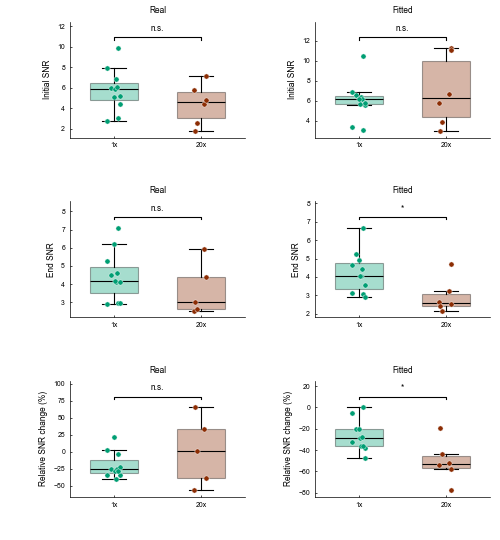

In [14]:
snr_fit_window_seconds = 10.0
snr_summary_window_seconds = 30.0
snr_summary_window_samples = int(round(snr_summary_window_seconds * sampling_rate_hz))
recalculated_snr_figure_path = Path('/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/Figure1_code/SLM_comparison_recalculated_snr_summary.svg')

def compute_measured_window_snr(snr_result, window_seconds=10.0):
    selected_spikes = np.asarray(snr_result['selected_spikes_for_height'], dtype=int)
    selected_heights = np.asarray(snr_result['selected_spike_heights'], dtype=float)
    baseline_std = np.asarray(snr_result['baseline_std'], dtype=float)
    fs = float(snr_result['sampling_rate_hz'])
    n_samples = len(np.asarray(snr_result['time_seconds'], dtype=float))
    window_samples = max(1, int(round(window_seconds * fs)))
    measured_window_snr = np.full(baseline_std.shape, np.nan, dtype=float)

    valid_height_mask = np.isfinite(selected_heights)
    selected_spikes = selected_spikes[valid_height_mask]
    selected_heights = selected_heights[valid_height_mask]

    for window_idx, baseline_value in enumerate(baseline_std):
        if not np.isfinite(baseline_value) or baseline_value <= 0:
            continue
        start = window_idx * window_samples
        end = min(n_samples, start + window_samples)
        in_window = (selected_spikes >= start) & (selected_spikes < end)
        if not np.any(in_window):
            continue
        median_height = np.nanmedian(selected_heights[in_window])
        if np.isfinite(median_height):
            measured_window_snr[window_idx] = median_height / baseline_value
    return measured_window_snr

def summarize_recalculated_snr(cell_result):
    with contextlib.redirect_stdout(io.StringIO()):
        snr_result = compute_time_varying_snr_from_trace(
            trace=cell_result['trace_SNR_interpolated'],
            spks=cell_result['all_spikes'],
            complex_burst_dict=cell_result['complex_bursts_dict'],
            sampling_rate_hz=sampling_rate_hz,
            isi_threshold_ms=20,
            spike_baseline_points=3,
            spike_remove_points=3,
            baseline_window_seconds=snr_fit_window_seconds,
            plot_single_cell=False,
        )

    measured_window_snr = compute_measured_window_snr(
        snr_result,
        window_seconds=snr_fit_window_seconds,
    )
    fit_window_starts_s = np.arange(measured_window_snr.size, dtype=float) * snr_fit_window_seconds
    fit_window_ends_s = fit_window_starts_s + snr_fit_window_seconds
    total_duration_s = len(cell_result['trace_SNR_interpolated']) / sampling_rate_hz
    initial_real_mask = fit_window_starts_s < snr_summary_window_seconds
    end_real_mask = fit_window_ends_s > max(0.0, total_duration_s - snr_summary_window_seconds)
    initial_real_window = measured_window_snr[initial_real_mask]
    end_real_window = measured_window_snr[end_real_mask]
    initial_real_snr = np.nanmean(initial_real_window) if np.any(np.isfinite(initial_real_window)) else np.nan
    end_real_snr = np.nanmean(end_real_window) if np.any(np.isfinite(end_real_window)) else np.nan

    fitted_snr = np.asarray(snr_result['snr_time_varying'], dtype=float)
    fitted_initial_window = fitted_snr[:snr_summary_window_samples]
    fitted_end_window = fitted_snr[-snr_summary_window_samples:]
    initial_fitted_snr = np.nanmean(fitted_initial_window) if np.any(np.isfinite(fitted_initial_window)) else np.nan
    end_fitted_snr = np.nanmean(fitted_end_window) if np.any(np.isfinite(fitted_end_window)) else np.nan

    def _drop_pct(initial_value, end_value):
        if not np.isfinite(initial_value) or not np.isfinite(end_value) or initial_value <= 0:
            return np.nan
        return (end_value - initial_value) / initial_value * 100.0

    return {
        'snr_result': snr_result,
        'measured_window_snr': measured_window_snr,
        'initial_real_snr': initial_real_snr,
        'end_real_snr': end_real_snr,
        'drop_real_pct': _drop_pct(initial_real_snr, end_real_snr),
        'initial_fitted_snr': initial_fitted_snr,
        'end_fitted_snr': end_fitted_snr,
        'drop_fitted_pct': _drop_pct(initial_fitted_snr, end_fitted_snr),
    }

recalc_snr_results = {'1x': [], '20x': []}
for condition_label in ('1x', '20x'):
    print(f'Recalculating SNR for {condition_label}...')
    for cell_idx, cell_result in enumerate(spike_results[condition_label], start=1):
        print(f'  {condition_label} cell {cell_idx}/{len(spike_results[condition_label])}')
        recalc_snr_results[condition_label].append(summarize_recalculated_snr(cell_result))

for condition_label in ('1x', '20x'):
    print(f'{condition_label} recalculated SNR mapping:')
    for idx, (info, result) in enumerate(zip(trace_info[condition_label], recalc_snr_results[condition_label]), start=1):
        print(
            f"  {idx}: {info['folder']} | "
            f"real {result['initial_real_snr']:.2f}->{result['end_real_snr']:.2f} ({result['drop_real_pct']:.2f}%) | "
            f"fitted {result['initial_fitted_snr']:.2f}->{result['end_fitted_snr']:.2f} ({result['drop_fitted_pct']:.2f}%)"
        )

def get_metric_array(condition_label, metric_name):
    values = np.array([
        result[metric_name]
        for result in recalc_snr_results[condition_label]
    ], dtype=float)
    return values[np.isfinite(values)]

def plot_snr_metric_comparison(ax, metric_1x, metric_20x, ylabel, column_title):
    box = ax.boxplot(
        [metric_1x, metric_20x],
        tick_labels=['1x', '20x'],
        widths=0.55,
        patch_artist=True,
        medianprops={'color': 'black', 'linewidth': 0.8},
        boxprops={'linewidth': 0.8},
        whiskerprops={'linewidth': 0.8},
        capprops={'linewidth': 0.8},
        showfliers=False,
    )
    for patch, color in zip(box['boxes'], [COLOR_1X, COLOR_20X]):
        patch.set_facecolor(color)
        patch.set_alpha(0.35)

    rng = np.random.default_rng(0)
    for x_pos, values, color in zip([1, 2], [metric_1x, metric_20x], [COLOR_1X, COLOR_20X]):
        jitter = rng.uniform(-0.08, 0.08, size=values.shape[0])
        ax.scatter(
            np.full(values.shape[0], x_pos) + jitter,
            values,
            s=14,
            color=color,
            edgecolors='white',
            linewidths=0.3,
            zorder=3,
        )

    p_value = np.nan
    if metric_1x.size > 0 and metric_20x.size > 0:
        p_value = ttest_ind(metric_1x, metric_20x, equal_var=False, nan_policy='omit').pvalue

    combined = np.concatenate([metric_1x, metric_20x]) if (metric_1x.size + metric_20x.size) else np.array([0.0])
    y_min = float(np.nanmin(combined))
    y_max = float(np.nanmax(combined))
    y_range = y_max - y_min if y_max > y_min else max(1.0, abs(y_max) * 0.2 + 1.0)
    line_y = y_max + 0.10 * y_range
    text_y = y_max + 0.18 * y_range
    if np.isfinite(p_value):
        significance_label = p_to_stars(p_value) or 'n.s.'
        ax.plot([1, 1, 2, 2], [line_y, line_y + 0.03 * y_range, line_y + 0.03 * y_range, line_y], color='black', linewidth=0.8)
        ax.text(1.5, text_y, significance_label, ha='center', va='bottom', fontsize=6)
    ax.set_ylim(y_min - 0.08 * y_range, y_max + 0.32 * y_range)
    ax.set_ylabel(ylabel)
    ax.set_title(column_title)
    ax.tick_params(length=1.75, width=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

snr_panel_specs = [
    ('initial_real_snr', 'initial_fitted_snr', 'Initial SNR', 'Real', 'Fitted'),
    ('end_real_snr', 'end_fitted_snr', 'End SNR', 'Real', 'Fitted'),
    ('drop_real_pct', 'drop_fitted_pct', 'Relative SNR change (%)', 'Real', 'Fitted'),
]

fig, axes = plt.subplots(3, 2, figsize=(5.0, 5.4))
for row_idx, (real_metric, fitted_metric, ylabel, left_title, right_title) in enumerate(snr_panel_specs):
    metric_real_1x = get_metric_array('1x', real_metric)
    metric_real_20x = get_metric_array('20x', real_metric)
    metric_fitted_1x = get_metric_array('1x', fitted_metric)
    metric_fitted_20x = get_metric_array('20x', fitted_metric)
    plot_snr_metric_comparison(axes[row_idx, 0], metric_real_1x, metric_real_20x, ylabel, left_title)
    plot_snr_metric_comparison(axes[row_idx, 1], metric_fitted_1x, metric_fitted_20x, ylabel, right_title)

fig.subplots_adjust(left=0.14, right=0.98, bottom=0.08, top=0.96, hspace=0.55, wspace=0.40)
fig.savefig(recalculated_snr_figure_path, format='svg', bbox_inches='tight')
print(f'Saved recalculated SNR summary figure to {recalculated_snr_figure_path}')
plt.show()
